## 数据加载的帮助函数
我们的datasets有两大类数据，一类是 ssvep数据，通过五通道头环采集的 .bdf数据集；一类是使用 16 通道openbci采集的 txt 数据。
这个Cell需要实现一个统一的数据加载类，能够支持两种格式。
类的功能需要至少有： 
+ 统一的数据加载并转换成 polars df
+ 数据元信息查询：输出数据的通道数、采样率、时长等元信息
+ 数据的直接使用和操作（只允许使用deepcopy或view，不改变原始数据）

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from pathlib import Path
import sys

# 支持从仓库根目录或 notebooks/ 目录启动 Jupyter 内核。
project_root = Path.cwd()
if not (project_root / "src" / "eeg_analysis.py").is_file():
    project_root = project_root.parent
if not (project_root / "src" / "eeg_analysis.py").is_file():
    raise FileNotFoundError("请从仓库根目录或 notebooks/ 目录运行本 notebook")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.eeg_analysis import (
    BandpassConfig,
    EEGDataset,
    EEGMetadata,
    EEG_BANDS,
    WaveletTFR,
    band_power_timeseries,
    morlet_tfr,
    plot_band_power,
    plot_filter_response,
    plot_tfr,
    plot_tfr_values,
    plot_time_and_frequency,
    specparam_tfr,
)

# 读取、预处理与分析的实现已集中在 eeg_analysis.py；notebook 仅保留实验配置和展示步骤。


## 数据的基本检查
对数据进行元信息打印

对现有的数据进行
+ 时域绘图
+ 频域绘图

[[注意，BDF里还有事件标记等数据，也需要补充绘制。一般的标记是时间窗口，可以用垂直线+不同颜色阴影表示]]

In [19]:
# 元信息检查：分别读取一份 BDF 和一份 OpenBCI TXT 数据。
sample_files = {
    "SSVEP BDF": "../datasets/SSVEP/训练eeg_7e845706-1ecc-4b8e-ab59-05c668cbbfb6.bdf",
    "OpenBCI TXT": "../datasets/Open BCI/2026-05-26_22-50-09 万臣 正常.txt",
}
sample_recordings = {name: EEGDataset(path) for name, path in sample_files.items()}

metadata_table = pl.DataFrame(
    [
        {
            "dataset": name,
            "format": recording.metadata.format,
            "n_channels": recording.metadata.n_channels,
            "sample_rate_hz": recording.metadata.sample_rate_hz,
            "n_samples": recording.metadata.n_samples,
            "duration_s": round(recording.metadata.duration_s, 3),
            "channels": ", ".join(recording.metadata.channels),
        }
        for name, recording in sample_recordings.items()
    ]
)

# 基础一致性检查：数据表必须由时间列和所有信号通道组成。
for recording in sample_recordings.values():
    assert recording.df.columns == ["time_s", *recording.metadata.channels]
    assert recording.df.height == recording.metadata.n_samples
    assert np.isclose(
        recording.metadata.duration_s,
        recording.metadata.n_samples / recording.metadata.sample_rate_hz,
    )

metadata_table

dataset,format,n_channels,sample_rate_hz,n_samples,duration_s,channels
str,str,i64,f64,i64,f64,str
"""SSVEP BDF""","""bdf""",5,250.0,21000,84.0,"""Fp2, O1, O2, C3, C4"""
"""OpenBCI TXT""","""openbci_txt""",16,125.0,13003,104.024,"""EXG Channel 0, EXG Channel 1, …"


In [20]:
# plot_time_and_frequency 已由 eeg_analysis 模块导入。
# 支持 channels="all" 和 duration_s="all"，便于对完整记录做快速检查。


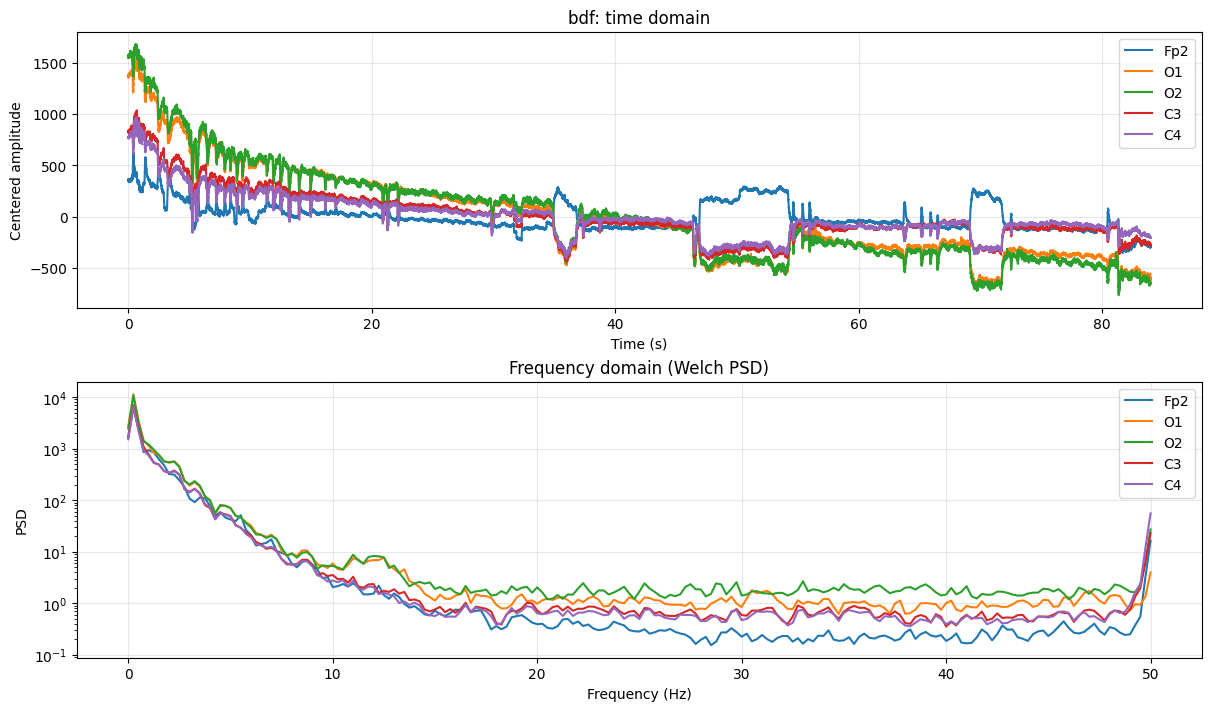

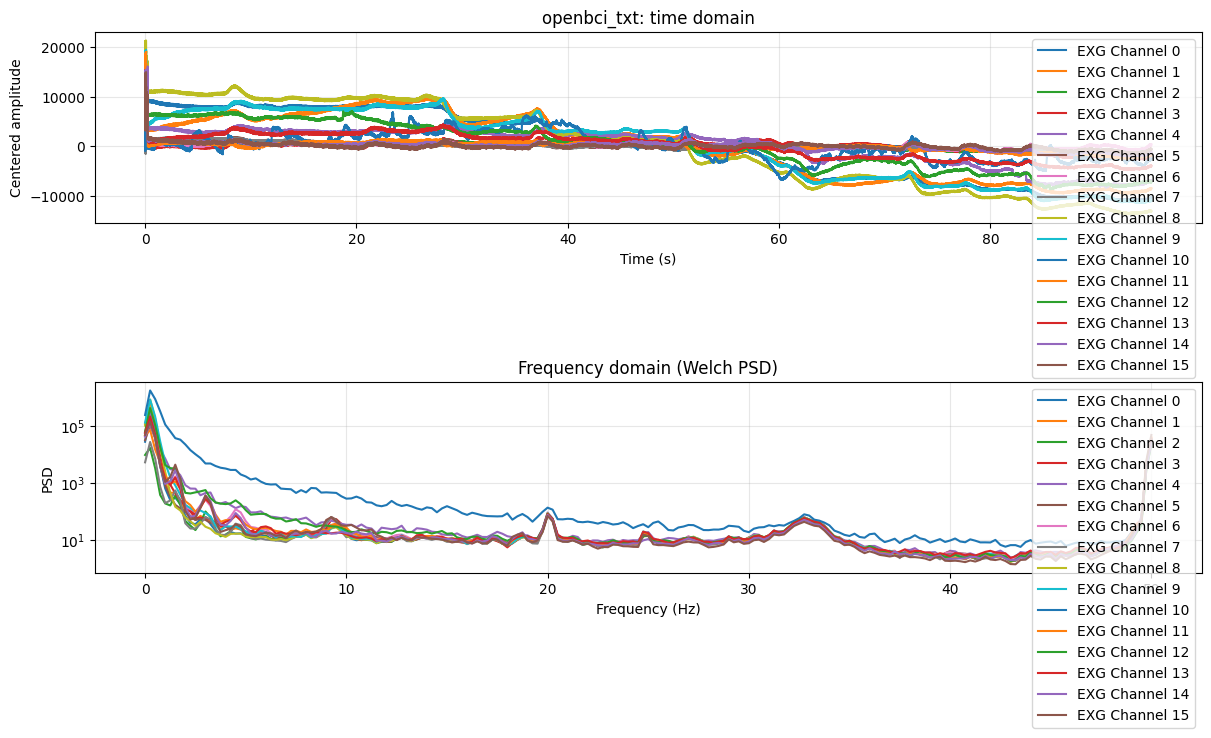

In [21]:
# BDF example: two occipital channels suited to SSVEP observation.
bdf_recording = EEGDataset("../datasets/SSVEP/训练eeg_7e845706-1ecc-4b8e-ab59-05c668cbbfb6.bdf")
plot_time_and_frequency(bdf_recording, channels="all", duration_s="all")
plt.show()

# OpenBCI TXT example: use the first two recorded EXG channels.
txt_recording = EEGDataset("../datasets/Open BCI/2026-05-26_22-20-22 万臣 闭眼测试.txt")
plot_time_and_frequency(txt_recording, channels="all", duration_s="all")
plt.show()


# 正式的数据处理
以 datasets/Open BCI/2026-05-26_22-20-22 万臣 闭眼测试.txt 为例

## 预处理
+ 1-40 Hz 带通滤波（同时抑制直流/慢漂移、50 Hz 工频与高频噪声）
+ 参考策略：保留采集时的耳夹硬件参考，不重复进行平均重参考
+ 去伪迹：眼电、肌电、运动伪迹，常用 ICA、ASR、阈值剔除

以下预处理针对示例 OpenBCI 记录逐步进行。每一步都在前一步结果的副本上处理，不改变原始载入数据。`1-40 Hz` 带通已经排除 `0 Hz` 直流并将 `50 Hz` 置于阻带，因此不额外重复去均值或陷波。该数据已通过耳夹电极差分放大得到硬件参考，因此不再做 average reference。伪迹处理使用鲁棒阈值检测后插值修复，以保持信号时间轴连续。

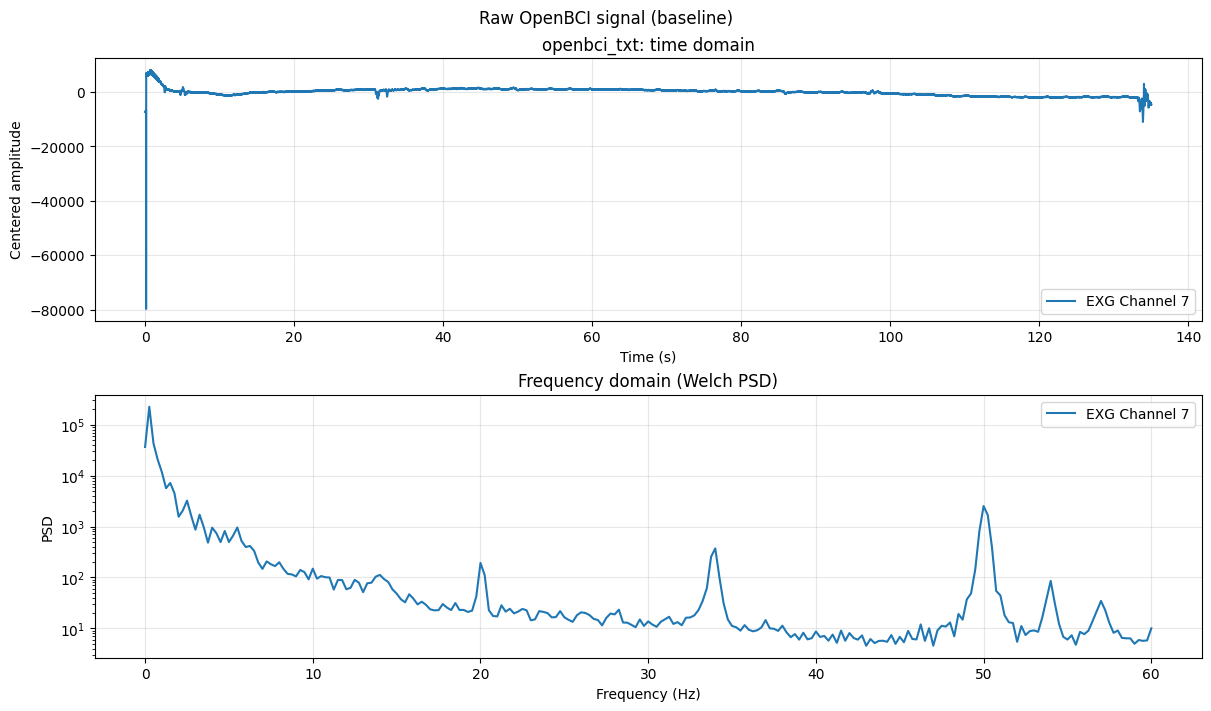

In [22]:
processing_raw = EEGDataset("../datasets/Open BCI/2026-05-28_21-58-46 邱学长 扫频.txt")
processing_channels = ["EXG Channel 7"]
processing_duration_s = "all"

fig, axes = processing_raw.plot(
    channels=processing_channels, duration_s=processing_duration_s, max_frequency_hz=60
)
fig.suptitle("Raw OpenBCI signal (baseline)")
plt.show()


### 不单独进行去直流
`1-40 Hz` 带通的高通部分已经排除 `0 Hz` 直流及慢漂移，因此不再额外进行逐通道减均值。

In [23]:
# DC removal is intentionally omitted: it is covered by the band-pass high-pass edge.


### 不单独进行工频陷波
`50 Hz` 已位于 `1-40 Hz` 带通的高频阻带。仅当后续需要保留 `40 Hz` 以上脑电内容时，再单独加入 `50 Hz` notch filter。

In [24]:
# Notch filtering is intentionally omitted: 50 Hz is outside the retained passband.


### 1. 带通滤波：同时排除直流、工频与频带外噪声
仅使用低通不会消除缓慢的基线漂移。这里使用 Butterworth 零相位带通滤波器：`passband_hz` 定义希望保留的频段，`stopband_hz` 定义必须明显衰减的频段，`buttord` 根据通带损失和阻带衰减要求自动计算阶数。

注意：`40 Hz` 是通带边缘，不代表从此处开始频谱立即为零。若希望截止更陡，可以缩小 `40-45 Hz` 的过渡带或提高 `stopband_attenuation_db`，代价是滤波阶数、振铃和边界效应增加。`sosfiltfilt` 会将滤波器应用两次，所以最终信号的 dB 衰减约为单次设计指标的两倍。

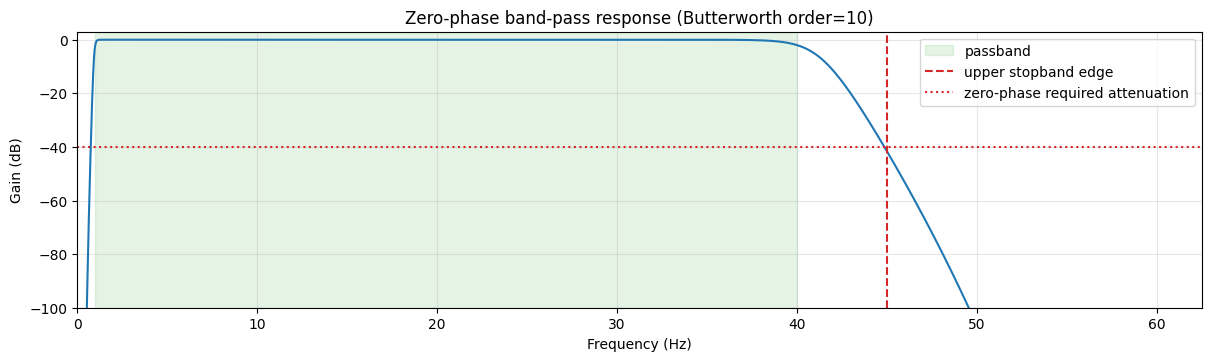

Designed Butterworth order: 10; critical frequencies: [ 0.9365575  41.16333498]


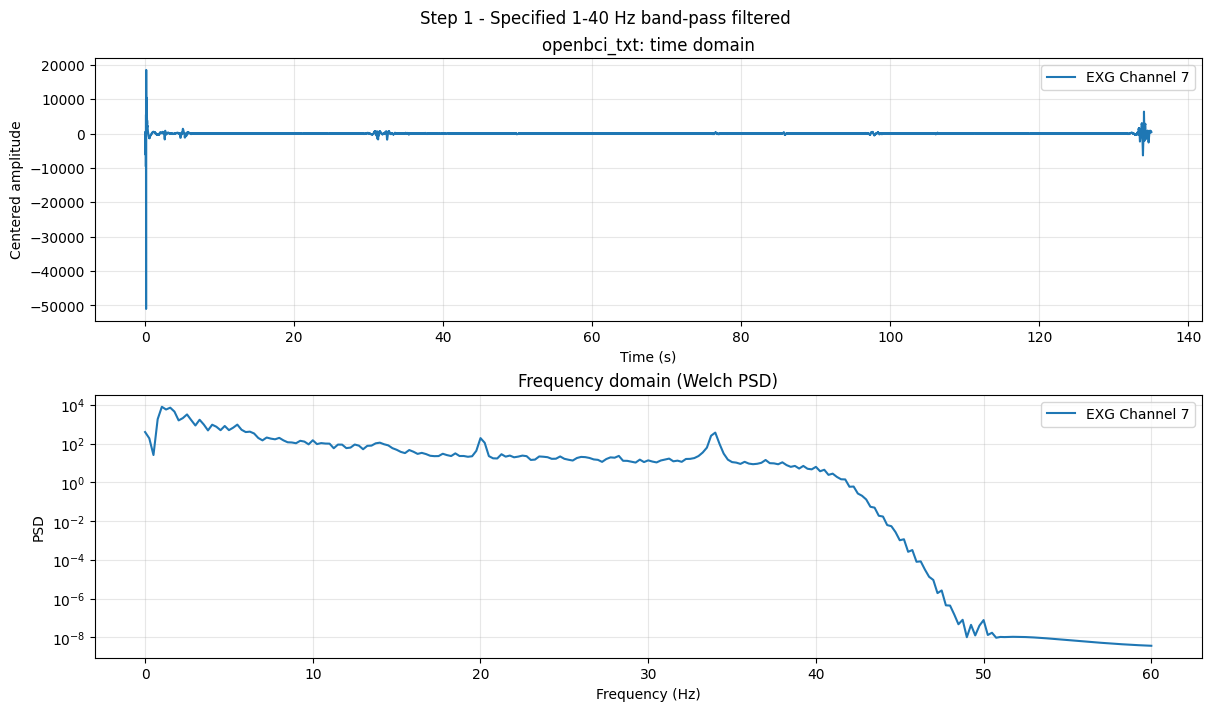

In [25]:
# 可调滤波规格：通带边缘、阻带边缘、容许通带损失与要求的单次阻带衰减。
filter_config = BandpassConfig(
    passband_hz=(1.0, 40.0),
    stopband_hz=(0.3, 45.0),
    passband_loss_db=1.0,
    stopband_attenuation_db=20.0,
)
preprocessing = processing_raw.preprocess(filter_config=filter_config, artifact_threshold=8.0)
filter_design = preprocessing.filter_design
bandpass_filtered = preprocessing.bandpass_filtered

fig, axis = plot_filter_response(filter_design)
plt.show()
print(
    f"Designed Butterworth order: {filter_design.order}; "
    f"critical frequencies: {filter_design.critical_hz}"
)

fig, axes = bandpass_filtered.plot(
    channels=processing_channels, duration_s=processing_duration_s, max_frequency_hz=60
)
fig.suptitle("Step 1 - Specified 1-40 Hz band-pass filtered")
plt.show()


### 2. 保留耳夹硬件参考
采集数据已经是各通道相对于耳夹电极的差分信号。再次进行 average reference 会把通道平均活动从每个通道中扣除，改变当前参考定义；因此这里显式保留硬件参考，仅复制上一阶段结果。

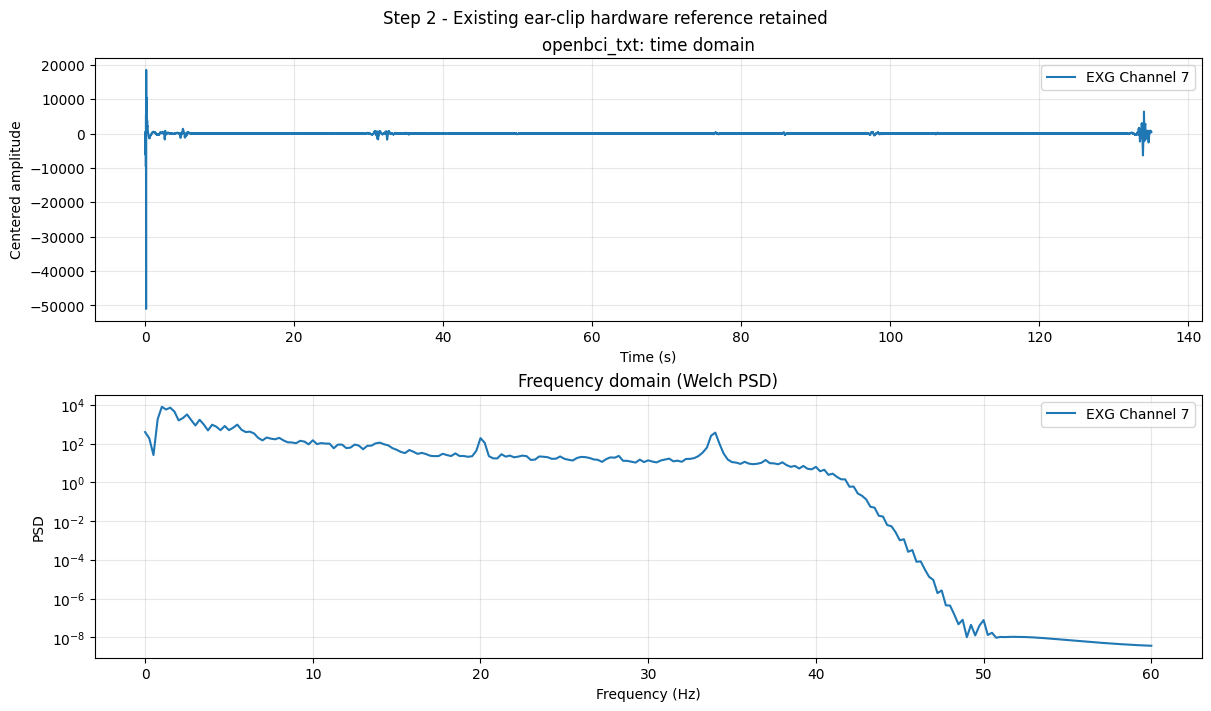

In [26]:
hardware_referenced = preprocessing.hardware_referenced

fig, axes = hardware_referenced.plot(
    channels=processing_channels, duration_s=processing_duration_s, max_frequency_hz=60
)
fig.suptitle("Step 2 - Existing ear-clip hardware reference retained")
plt.show()


### 3. 阈值伪迹处理
以带通信号中各通道的 median absolute deviation (MAD) 估计鲁棒尺度；每个通道独立标记超出 8 倍鲁棒尺度的采样值，并只对该通道对应位置进行时间轴线性插值。修复应用于未滤波原始数据，之后再执行一次带通作为最终输出，从而不重新引入 `40 Hz` 以上的频率成分。

逐通道修复避免一个电极的瞬态异常导致同时删除其余通道的有效观测。该步骤适合作为初步清洗，后续若有电极布局与更多样本可进一步引入 ICA/ASR。


In [27]:
# artifact_cleaned = preprocessing.cleaned
# artifact_report = preprocessing.artifacts
# artifact_mask = artifact_report.mask

# print(
#     f"Artifact channel-values repaired: {artifact_report.repaired_values} / {artifact_mask.size} "
#     f"({artifact_report.repaired_values / artifact_mask.size:.2%}); "
#     f"affected time samples: {artifact_report.affected_samples} / {artifact_mask.shape[0]}"
# )
# print(artifact_report.summary())

# fig, axes = artifact_cleaned.plot(
#     channels=processing_channels, duration_s=processing_duration_s, max_frequency_hz=60
# )
# fig.suptitle("Step 3 - Per-channel threshold artifacts interpolated")
# plt.show()

# preprocessing_stages = preprocessing.stages


## 基本脑电分析：频段检测
检测常见频段：
| 节律    |        频段 | 常见含义                   |
| ----- | --------: | ---------------------- |
| Delta |  0.5–4 Hz | 睡眠、慢波、病理慢波             |
| Theta |    4–8 Hz | 困倦、认知控制、记忆任务           |
| Alpha |   8–13 Hz | 放松、闭眼、视觉皮层抑制           |
| Mu    |   8–13 Hz | 中央区感觉运动节律，和 alpha 频段重叠 |
| Beta  |  13–30 Hz | 运动控制、注意、警觉；也容易混入肌电     |
| Gamma | 30–80+ Hz | 高频活动，但 EEG 中很容易被肌电污染   | 我们不做


### 小波变换：观察频段能量如何随时间改变

前面绘制的 Welch PSD 回答的是：**整段记录总体上包含哪些频率成分？** 它把所有时间点汇总为一条频谱，因此无法回答某个节律是在何时增强或减弱的。例如闭眼过程中 alpha (`8-13 Hz`) 可能并非一直稳定存在，而是在不同时间段出现波动。小波变换用于同时保留时间和频率信息。

#### 1. 连续小波变换（CWT）的直觉

小波是一段长度有限、会振荡并逐渐衰减的模板波形。对 EEG 信号 $x(t)$，连续小波变换可以写作：

$$
W_x(a, b) = \frac{1}{\sqrt{|a|}} \int x(t)\, \psi^*\left(\frac{t-b}{a}\right)\,dt
$$

其中：

- $b$ 表示模板沿时间轴移动到的位置，因此保留了**发生时间**。
- $a$ 表示尺度（scale）：尺度越大，小波越长、对应越低频；尺度越小，小波越短、对应越高频。
- $W_x(a,b)$ 是该时间点、该尺度下信号与小波的相似程度。
- $|W_x(a,b)|^2$ 常作为该时间与频率位置上的功率或能量指标。

与只使用一组覆盖全程的正弦波进行分解的傅里叶变换相比，小波使用局部模板滑过信号，因此适合分析 EEG 中随时间变化的节律和短暂事件。

#### 2. Morlet 小波为什么常用于 EEG

Morlet 小波可以理解为一个被高斯窗包裹的复数正弦波：

$$
\psi(t) = e^{i 2\pi f_0 t}\, e^{-t^2/(2\sigma^2)}
$$

中间的振荡部分用于匹配某一频率，外侧的高斯窗使分析局限在某一小段时间内。复数形式同时提供幅度和相位信息；在本节中主要使用其功率 $|W|^2$。

Morlet 小波的关键参数是周期数（number of cycles）：

- 周期数少：小波较短，时间定位更准确，但频率区分更模糊。
- 周期数多：小波较长，频率区分更准确，但瞬时变化会被时间平均。
- EEG 分析中可令周期数随频率增加，例如低频使用较少周期、高频使用较多周期，以在两种分辨率间折中。

#### 3. Time-Frequency Representation（TFR）

对一组感兴趣频率分别计算 Morlet 小波变换，并把 $|W|^2$ 排列为矩阵，就得到时频表示（TFR）：

- 横轴：时间（秒）。
- 纵轴：频率（Hz）。
- 颜色：该时间点附近、该频率附近的功率。

TFR 热图可以用来观察：闭眼数据中 alpha 能量是否在 `8-13 Hz` 形成持续或间歇的高能区域；不同通道的 alpha 表现是否一致；运动或接触伪迹是否表现为跨多个频段的突发高能量。

#### 4. 与当前数据处理流程的关系

本 notebook 后续应对清洗后的 `artifact_cleaned` 计算 TFR，而不是对原始记录直接分析。当前预处理保留 `1-40 Hz` 内容，因此适合分析 Delta、Theta、Alpha、Mu 与 Beta；`40 Hz` 以上的 Gamma 不应由这份预处理结果解释。

还需要注意两点：

- 小波本身在每段数据的首尾会有边界效应（cone of influence），靠近开始和结束位置的能量解释要谨慎。
- 功率通常跨数量级变化，绘图时常使用对数功率，或相对基线的 dB 变化；对于当前连续闭眼记录，可先绘制绝对对数功率，再决定是否需要基线归一化。

下一步将使用 Morlet 小波生成每个通道的 TFR，并汇总各 EEG 频段的功率随时间变化。

In [28]:
# 计算与绘图函数已从 src.eeg_analysis 导入，可在其它 notebook 或脚本中直接复用。


## 小波变换和时频图展示

下面对预处理后的 `artifact_cleaned` 数据执行 Morlet 小波分析。为避免一张图同时放入 16 个通道而难以阅读，TFR 以每组 4 个通道分页展示。先绘制绝对功率（dB）热图，再绘制相对功率热图：后者在每个通道、每个时间点上，将每个频率的功率除以 `1-40 Hz` 全部分析频率的功率和，颜色表示该频率成分的瞬时能量占比。最后绘制每个通道在 `Delta`、`Theta`、`Alpha`、`Beta` 四个频段中的功率随时间变化。

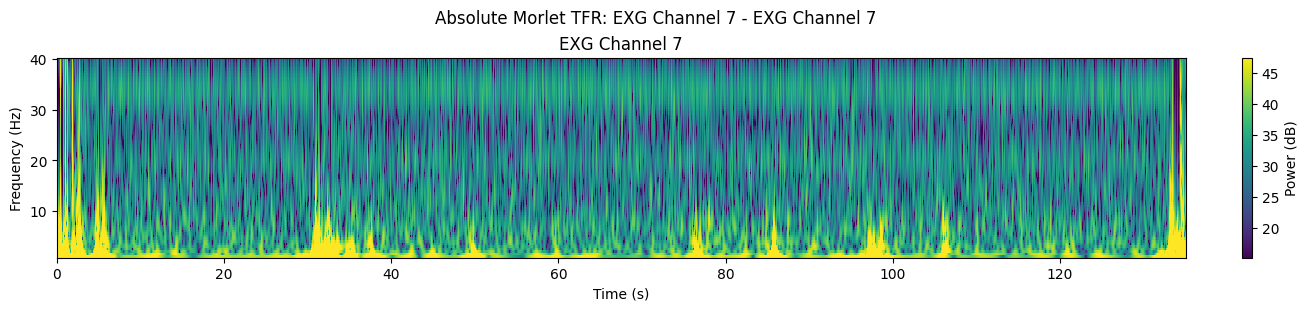

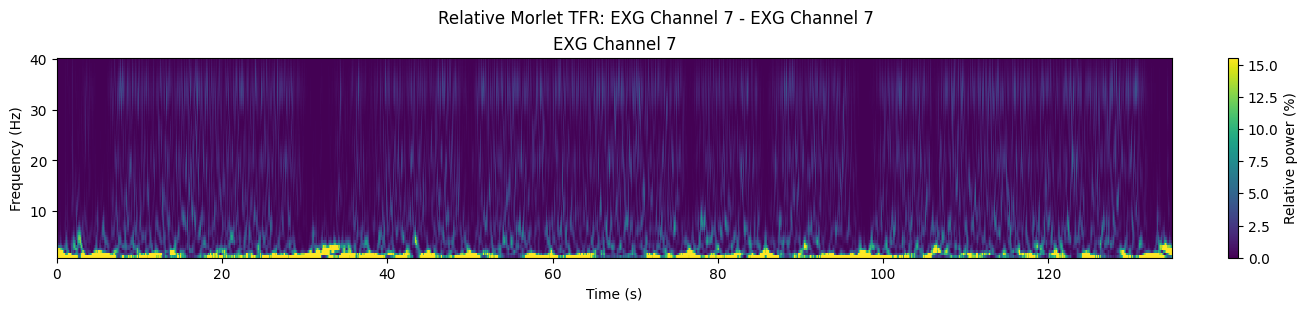

In [29]:
# 对全部通道计算一次 TFR，后续所有展示复用该结果。
analysis_tfr = artifact_cleaned.wavelet_transform(
    channels=processing_channels,
    frequencies_hz=np.arange(1.0, 40.5, 0.5),
    n_cycles=np.linspace(3.0, 10.0, 79),
)

display_channel_groups = [
    list(analysis_tfr.channels[start : start + 4])
    for start in range(0, len(analysis_tfr.channels), 4)
]
for group in display_channel_groups:
    fig, axes = plot_tfr(analysis_tfr, channels=group)
    fig.suptitle(f"Absolute Morlet TFR: {group[0]} - {group[-1]}")
    plt.show()
    plt.close(fig)

for group in display_channel_groups:
    fig, axes = plot_tfr(analysis_tfr, channels=group, relative=True)
    fig.suptitle(f"Relative Morlet TFR: {group[0]} - {group[-1]}")
    plt.show()
    plt.close(fig)


## 对数功率图

小波功率 $|W(f,t)|^2$ 的数值跨度通常很大，因此使用 $10\log_{10}(P)$ 转换为 dB 显示。对数功率仍保留低频整体能量更高这一真实特征，适合判断绝对能量结构；它不是对 `1/f` 背景的校正。

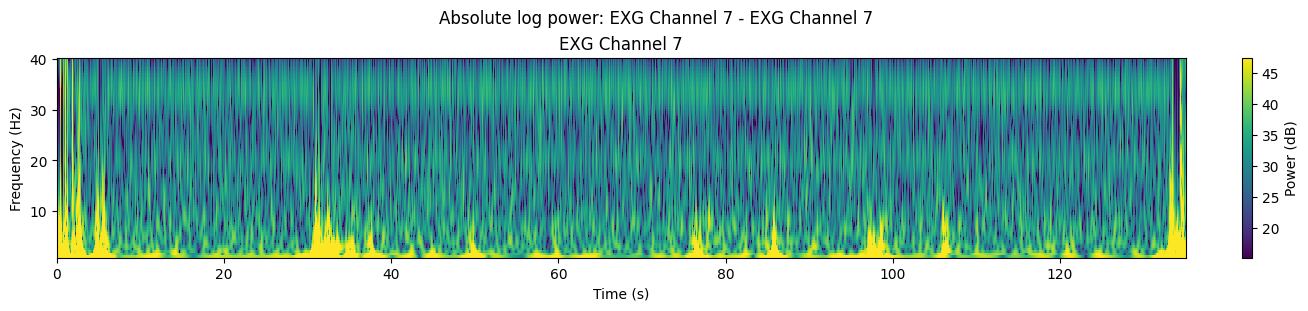

In [30]:
absolute_log_power_db = analysis_tfr.log_power_db
for group in display_channel_groups:
    fig, axes = plot_tfr_values(
        analysis_tfr, absolute_log_power_db, channels=group,
        title=f"Absolute log power: {group[0]} - {group[-1]}",
        color_label="Power (dB)",
    )
    plt.show()
    plt.close(fig)


## 自差异：相对自身时间平均功率

相对总功率图会被天然较强的低频成分主导。这里对每个通道、每个频率分别计算其相对于整段记录中该频率平均功率的 dB 变化：

$$
\Delta P(f,t) = 10\log_{10}\frac{P(f,t)}{\overline{P(f)}}
$$

因此每一行频率都与自身背景比较：红色表示该频率在该时段高于自身平均，蓝色表示低于自身平均。该视图适合观察 Delta 到 Beta 中的节律何时增强，但不用于比较不同频率谁的绝对能量更大。

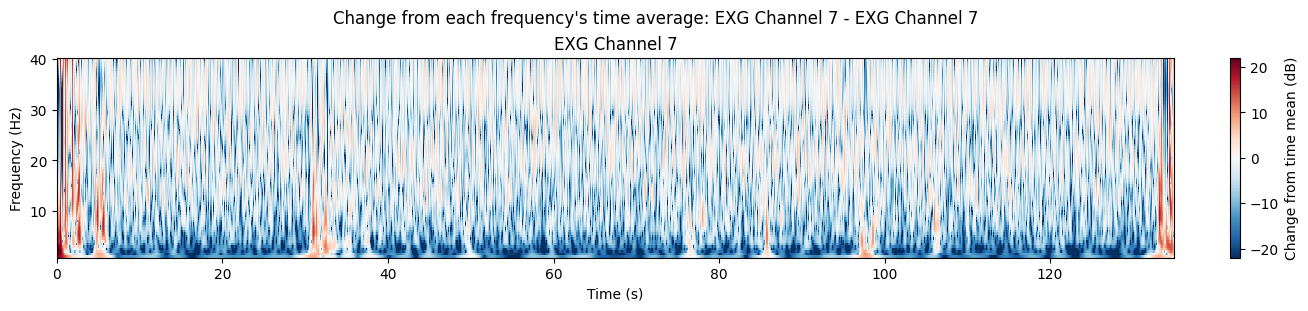

In [31]:
frequency_time_mean_power = analysis_tfr.power.mean(axis=2, keepdims=True)
frequency_self_difference_db = 10 * np.log10(
    np.maximum(analysis_tfr.power, np.finfo(float).eps)
    / np.maximum(frequency_time_mean_power, np.finfo(float).eps)
)

for group in display_channel_groups:
    fig, axes = plot_tfr_values(
        analysis_tfr, frequency_self_difference_db, channels=group,
        title=f"Change from each frequency's time average: {group[0]} - {group[-1]}",
        color_label="Change from time mean (dB)", cmap="RdBu_r", symmetric=True,
    )
    plt.show()
    plt.close(fig)


## Specparam 风格谱分解：非周期背景与周期峰

简单白化使用一条直线拟合整个对数频谱，谱峰本身会影响背景估计。这里改用 `specparam`（原 FOOOF）的模型化方法：将每个通道的中位功率谱拆分为非周期 `1/f` 背景（aperiodic component）和高于背景的周期峰（periodic peaks）。

模型只在 `2-38 Hz` 拟合，避开 `1-40 Hz` 带通滤波器两端的过渡区。输入给模型的是线性功率，而非 dB 功率；得到非周期背景后，再从逐时间点的对数 TFR 中扣除背景。校正后大于 `0 dB` 的区域表示该时间、频率功率高于模型估计的非周期背景。

峰参数表中的 `center_frequency_hz`、`peak_power_above_background_db` 与 `bandwidth_hz` 分别描述候选周期峰的位置、超过背景的高度和宽度。被检测为峰仍不等价于神经来源：跨所有通道和实验条件一致出现的峰仍需要优先排查采集链或刺激干扰。

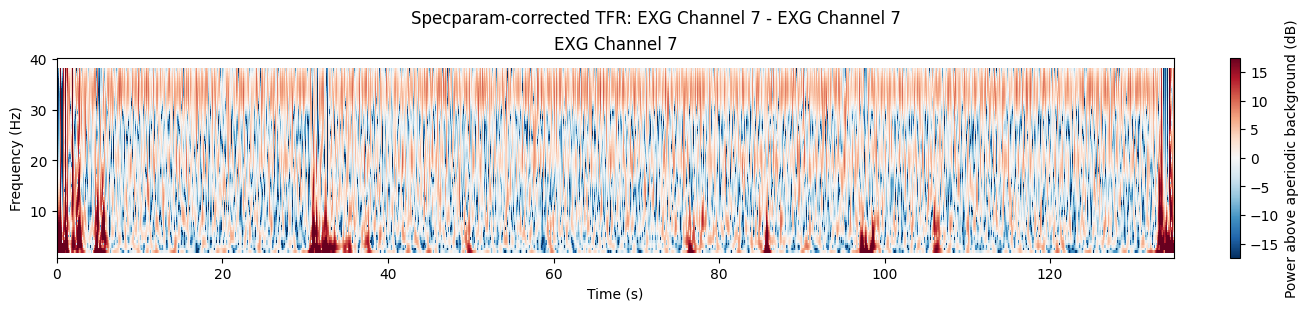

(shape: (1, 4)
 ┌───────────────┬─────────────────────┬────────────────────────────────┬──────────────┐
 │ channel       ┆ center_frequency_hz ┆ peak_power_above_background_db ┆ bandwidth_hz │
 │ ---           ┆ ---                 ┆ ---                            ┆ ---          │
 │ str           ┆ f64                 ┆ f64                            ┆ f64          │
 ╞═══════════════╪═════════════════════╪════════════════════════════════╪══════════════╡
 │ EXG Channel 7 ┆ 33.999076           ┆ 5.731646                       ┆ 5.021311     │
 └───────────────┴─────────────────────┴────────────────────────────────┴──────────────┘,
 shape: (1, 2)
 ┌───────────────┬─────────────────────────────────┐
 │ channel       ┆ median_alpha_above_background_… │
 │ ---           ┆ ---                             │
 │ str           ┆ f64                             │
 ╞═══════════════╪═════════════════════════════════╡
 │ EXG Channel 7 ┆ -0.500466                       │
 └───────────────┴──────────

In [32]:
specparam_frequency_range_hz = (2.0, 38.0)
specparam_result = specparam_tfr(analysis_tfr, fit_range_hz=specparam_frequency_range_hz)
model_frequency_mask = specparam_result.frequency_mask
aperiodic_background_db = specparam_result.aperiodic_background_db
specparam_corrected_tfr_db = specparam_result.corrected_tfr_db
specparam_models = specparam_result.models
specparam_peaks = specparam_result.peaks

for group in display_channel_groups:
    fig, axes = plot_tfr_values(
        analysis_tfr, specparam_corrected_tfr_db, channels=group,
        title=f"Specparam-corrected TFR: {group[0]} - {group[-1]}",
        color_label="Power above aperiodic background (dB)", cmap="RdBu_r", symmetric=True,
    )
    plt.show()
    plt.close(fig)

alpha_specparam_summary = (
    specparam_result.band_summary({"Alpha": (8.0, 13.0)})
    .drop("band")
    .rename({"median_power_above_background_db": "median_alpha_above_background_db"})
    .sort("median_alpha_above_background_db", descending=True)
)

specparam_peaks.sort("peak_power_above_background_db", descending=True), alpha_specparam_summary


# SSVEP 检测
只针对 `datasets/SSVEP/` 下的记录。本节直接复用前文已完成带通滤波和伪迹修复的 `artifact_cleaned`，不重复执行通用预处理。

检测只取视觉枕区通道 `O1`、`O2`，候选刺激模板为 `8`、`9`、`10`、`11 Hz`，使用 [SSVEP Analysis Toolbox](https://github.com/pikipity/SSVEP-Analysis-Toolbox) 提供的 FBCCA 进行频率识别。

## FBCCA 方法与依赖说明

SSVEP 会在枕区 EEG 中产生与视觉闪烁频率及其谐波同步的周期响应。CCA 将 EEG 窗口与每个候选频率的正弦/余弦参考模板比较，相关性最高的模板作为预测频率。FBCCA 分别在多个子频带上计算 CCA 并加权合并分数，使基频与谐波响应都参与判断。

本节使用三个 filter bank：`6-40 Hz`、`14-40 Hz`、`22-40 Hz`。前文预处理仅保留到 `40 Hz`，因此这里覆盖候选刺激频率的基频、二次与三次谐波范围，不解释更高频内容。检测采用 `4 s` 窗口、`2 s` 步长，并忽略每段刺激开始后的前 `0.5 s` 瞬态。

> 兼容性提示：当前 `SSVEPAnalysisToolbox==0.0.5` 的发布依赖限制在旧版 NumPy/SciPy/Matplotlib，而本项目使用更新的科学计算栈，因此暂不把该库写入项目锁文件。运行本节前，可在本地实验环境执行：
>
> ```bash
> uv pip install --no-deps SSVEPAnalysisToolbox==0.0.5
> uv pip install joblib scikit-learn mat73
> ```
>
> 该版本导入时还依赖已从 NumPy 2 移除的 `np.object`，并且 `predict()` 的最终标签转换不兼容 NumPy 2；下方代码只在导入时提供旧别名，并复用工具箱 FBCCA 相关性计算后执行兼容的 `argmax`。工具箱发布兼容 NumPy 2 的版本后，应移除这些处理并改为正式项目依赖。

In [33]:
from scipy.signal import butter, sosfiltfilt

# SSVEPAnalysisToolbox 0.0.5 仍从 numpy 导入旧的 object 别名；只在导入期间补回该别名。
toolbox_needs_numpy_object_compat = "object" not in np.__dict__
if toolbox_needs_numpy_object_compat:
    setattr(np, "object", object)
try:
    from SSVEPAnalysisToolbox.algorithms import SCCA_qr
    from SSVEPAnalysisToolbox.algorithms.cca import _r_cca_qr
    from SSVEPAnalysisToolbox.utils.algsupport import gen_ref_sin
finally:
    if toolbox_needs_numpy_object_compat:
        delattr(np, "object")

ssvep_recording = artifact_cleaned
ssvep_channels = ["O1", "O2"]
stimulus_frequencies_hz = np.array([8.0, 10.0, 9.0, 11.0])

# 训练 BDF 的事件标记：41/42/43/44 为刺激开始，9 为该段刺激结束。
# 如果采集程序的 marker-frequency 映射调整，只需修改这个映射表。
#BUG:这个映射表肯定不对。因为事实上的实验是四个刺激块以不同频率同时闪烁，让受试去看某一个特定的块，而不是每个块单独闪烁。marker处的频率是一个后验的eval指标，而不应该是一个先验的输入。
marker_to_frequency_hz = {41: 8.0, 42: 10.0, 43: 9.0, 44: 11.0}
ssvep_events = pl.DataFrame(
    {
        "marker": [41, 43, 42, 44],
        "start_s": [12.040, 29.036, 46.048, 63.056],
        "stop_s": [24.040, 41.052, 58.048, 75.056],
    }
).with_columns(
    pl.col("marker").replace_strict(marker_to_frequency_hz, return_dtype=pl.Float64).alias("expected_frequency_hz")
)

ssvep_events


ModuleNotFoundError: No module named 'SSVEPAnalysisToolbox'

## 从已清洗记录构造 FBCCA 窗口

`artifact_cleaned` 已经是前文通用预处理输出。这里新增的滤波仅用于构造 FBCCA 的 filter banks：各子频带看见的谐波范围不同，但全部源自同一份清洗后 EEG。事件区间被切成多个固定长度窗口，每个窗口保留刺激标签以检查检测效果。

In [ ]:
sample_rate_hz = ssvep_recording.metadata.sample_rate_hz
window_s = 4.0
step_s = 2.0
onset_latency_s = 0.5
window_samples = int(round(window_s * sample_rate_hz))

filterbank_hz = [(6.0, 40.0), (14.0, 40.0), (22.0, 40.0)]
filterbank_weights = [(index + 1) ** -1.25 + 0.25 for index in range(len(filterbank_hz))]
occipital_values = ssvep_recording.select(ssvep_channels).select(ssvep_channels).to_numpy().T
filterbank_values = np.stack(
    [
        sosfiltfilt(
            butter(4, band, btype="bandpass", fs=sample_rate_hz, output="sos"),
            occipital_values,
            axis=1,
        )
        for band in filterbank_hz
    ],
    axis=0,
)

ssvep_trials = []
expected_class_index = []
window_rows = []
for event in ssvep_events.iter_rows(named=True):
    start_s = event["start_s"] + onset_latency_s
    while start_s + window_s <= event["stop_s"] + 1e-9:
        first_sample = int(round(start_s * sample_rate_hz))
        last_sample = first_sample + window_samples
        ssvep_trials.append(filterbank_values[:, :, first_sample:last_sample])
        expected_index = int(np.flatnonzero(stimulus_frequencies_hz == event["expected_frequency_hz"])[0])
        expected_class_index.append(expected_index)
        window_rows.append(
            {"marker": event["marker"], "window_start_s": start_s, "expected_frequency_hz": event["expected_frequency_hz"]}
        )
        start_s += step_s

print(
    f"FBCCA input: {len(ssvep_trials)} windows, {len(filterbank_hz)} filter banks, "
    f"{len(ssvep_channels)} channels, {window_samples} samples/window"
)


FBCCA input: 16 windows, 3 filter banks, 2 channels, 1000 samples/window


## 运行 FBCCA 并评估窗口识别结果

`SCCA_qr` 在工具箱中通过多个 filter bank 输入及加权分数组合实现 FBCCA。该方法不需要用当前数据拟合训练模板；`fit()` 在这里注册四个刺激频率的正弦/余弦参考信号，每个参考包含三次谐波。由于工具箱 `0.0.5` 的 `predict()` 最后一行不支持 NumPy 2，本节调用同一工具箱内部的 `_r_cca_qr()` 计算各 filter bank 的 CCA 相关性，再使用等价的加权 `argmax` 得到标签。此处准确率是对当前记录已知刺激段的窗口级核对，不等同于独立在线数据上的泛化性能。

In [ ]:
reference_signals = [
    gen_ref_sin(freq=float(frequency_hz), srate=int(sample_rate_hz), L=window_samples, N=3, phase=0.0)
    for frequency_hz in stimulus_frequencies_hz
]

fbcca_model = SCCA_qr(weights_filterbank=filterbank_weights)
fbcca_model.fit(ref_sig=reference_signals)
weights = np.asarray(filterbank_weights)
filterbank_correlations = [
    _r_cca_qr(
        trial,
        n_component=fbcca_model.n_component,
        Y_Q=fbcca_model.model["ref_sig_Q"],
        Y_R=fbcca_model.model["ref_sig_R"],
        Y_P=fbcca_model.model["ref_sig_P"],
        force_output_UV=False,
    )
    for trial in ssvep_trials
]
combined_scores = np.vstack([weights @ trial_correlations for trial_correlations in filterbank_correlations])
predicted_class_index = np.argmax(combined_scores, axis=1)
predicted_frequency_hz = stimulus_frequencies_hz[np.asarray(predicted_class_index)]
expected_frequency_hz = np.asarray([row["expected_frequency_hz"] for row in window_rows])
window_results = pl.DataFrame(window_rows).with_columns(
    pl.Series("predicted_frequency_hz", predicted_frequency_hz),
    pl.Series("correct", predicted_frequency_hz == expected_frequency_hz),
    pl.Series("winning_fbcca_score", combined_scores.max(axis=1)),
)

overall_accuracy = window_results["correct"].mean()
frequency_accuracy = (
    window_results.group_by("expected_frequency_hz")
    .agg(pl.len().alias("windows"), pl.col("correct").mean().alias("accuracy"))
    .sort("expected_frequency_hz")
)
marker_prediction_summary = (
    window_results.group_by(["marker", "expected_frequency_hz", "predicted_frequency_hz"])
    .agg(pl.len().alias("windows"))
    .sort(["marker", "predicted_frequency_hz"])
)
print(f"Window-level FBCCA accuracy: {overall_accuracy:.2%}")
frequency_accuracy, marker_prediction_summary, window_results


Window-level FBCCA accuracy: 37.50%


(shape: (4, 3)
 ┌───────────────────────┬─────────┬──────────┐
 │ expected_frequency_hz ┆ windows ┆ accuracy │
 │ ---                   ┆ ---     ┆ ---      │
 │ f64                   ┆ u32     ┆ f64      │
 ╞═══════════════════════╪═════════╪══════════╡
 │ 8.0                   ┆ 4       ┆ 0.25     │
 │ 9.0                   ┆ 4       ┆ 0.25     │
 │ 10.0                  ┆ 4       ┆ 0.0      │
 │ 11.0                  ┆ 4       ┆ 1.0      │
 └───────────────────────┴─────────┴──────────┘,
 shape: (9, 4)
 ┌────────┬───────────────────────┬────────────────────────┬─────────┐
 │ marker ┆ expected_frequency_hz ┆ predicted_frequency_hz ┆ windows │
 │ ---    ┆ ---                   ┆ ---                    ┆ ---     │
 │ i64    ┆ f64                   ┆ f64                    ┆ u32     │
 ╞════════╪═══════════════════════╪════════════════════════╪═════════╡
 │ 41     ┆ 8.0                   ┆ 8.0                    ┆ 1       │
 │ 41     ┆ 8.0                   ┆ 9.0                    ┆ 1 

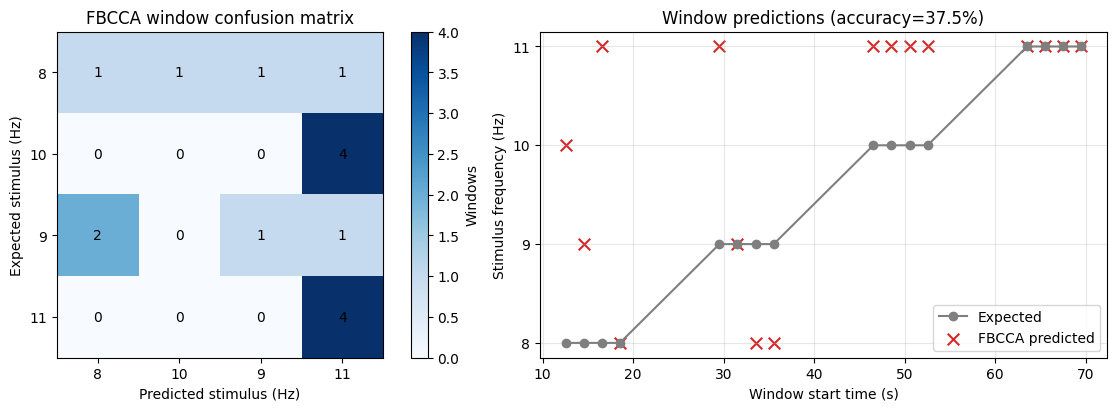

In [ ]:
confusion = np.zeros((len(stimulus_frequencies_hz), len(stimulus_frequencies_hz)), dtype=int)
for expected, predicted in zip(expected_class_index, predicted_class_index):
    confusion[expected, predicted] += 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
image = axes[0].imshow(confusion, cmap="Blues")
axes[0].set(
    title="FBCCA window confusion matrix", xlabel="Predicted stimulus (Hz)", ylabel="Expected stimulus (Hz)",
    xticks=np.arange(len(stimulus_frequencies_hz)), yticks=np.arange(len(stimulus_frequencies_hz)),
    xticklabels=stimulus_frequencies_hz.astype(int), yticklabels=stimulus_frequencies_hz.astype(int),
)
for expected in range(confusion.shape[0]):
    for predicted in range(confusion.shape[1]):
        axes[0].text(predicted, expected, confusion[expected, predicted], ha="center", va="center")
fig.colorbar(image, ax=axes[0], label="Windows")

axes[1].plot(
    window_results["window_start_s"], window_results["expected_frequency_hz"], marker="o", label="Expected", color="tab:gray"
)
axes[1].scatter(
    window_results["window_start_s"], window_results["predicted_frequency_hz"], marker="x", s=70, label="FBCCA predicted", color="tab:red"
)
axes[1].set(
    title=f"Window predictions (accuracy={overall_accuracy:.1%})", xlabel="Window start time (s)",
    ylabel="Stimulus frequency (Hz)", yticks=stimulus_frequencies_hz,
)
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.show()


## 结果解读与下一步检查

首先查看 `marker_prediction_summary`：同一 marker 在多个窗口中的预测是否稳定，再查看它与 `marker_to_frequency_hz` 的期望映射是否一致。当前 marker 到频率的字典必须与刺激程序的 trigger 定义核对；如果映射未经确认，窗口准确率只能用于排查流程，不能作为算法性能结论。

若映射确认后准确率仍低，按以下顺序排查：

1. 在 `O1`、`O2` 的谱图中确认刺激基频或谐波是否高于背景。
2. 检查每段事件起止时间、刺激开始延迟和眼动/接触伪迹影响。
3. 比较不同窗口长度、filter bank 范围和谐波数，但避免在同一记录上反复调参后报告无偏性能。
4. 在参数确定后，将同样检测流程应用到独立的在线记录进行验证。